Question 8 - Classification Topic 1: Student Pass/Fail Prediction

 Build a classifier that predicts whether a student will pass or fail.

 Tasks

 a) Create or load a dataset with at least 20 students and the columns Hours_Studied, Attendance, Practice_Quiz_Avg, Previous_GPA, and Pass.

 b) Create at least two visualizations that help you judge whether Pass and Fail seem easy or hard to separate.

 c) Define X and y for the classification task, then split the data into training and test sets.

 d) Train a DecisionTreeClassifier with max_depth=2.

 e) Predict on the test set and compute the confusion matrix, accuracy, precision, recall, and F1-score.

 f) Interpret TP, TN, FP, and FN in the context of student pass prediction.

 g) Create three new unseen student cases and predict whether each one will pass or fail.

 Required written reflection

 - Why is this a classification problem and not a regression problem?

 - What does a false positive mean in this task?

 - Which metric would you trust most here, and why?

In [3]:
# a) Create or load a dataset with at least 20 students and the columns Hours_Studied, Attendance, Practice_Quiz_Avg, Previous_GPA, and Pass.

import pandas as pd

data = {
    "Hours_Studied": [5, 8, 2, 6, 9, 3, 7, 4, 10, 1,
                      6, 8, 2, 5, 9, 7, 3, 4, 6, 8],

    "Attendance": [80, 90, 60, 75, 95, 65, 85, 70, 98, 50,
                   78, 88, 55, 72, 93, 82, 68, 74, 79, 87],

    "Practice_Quiz_Avg": [70, 85, 50, 65, 90, 55, 80, 60, 95, 40,
                         68, 82, 45, 66, 91, 78, 58, 63, 72, 84],

    "Previous_GPA": [2.5, 3.2, 1.8, 2.7, 3.8, 2.0, 3.0, 2.4, 3.9, 1.5,
                     2.8, 3.3, 1.7, 2.6, 3.7, 3.1, 2.2, 2.5, 2.9, 3.4],

    "Pass": [1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
             1, 1, 0, 1, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)

print(df)



    Hours_Studied  Attendance  Practice_Quiz_Avg  Previous_GPA  Pass
0               5          80                 70           2.5     1
1               8          90                 85           3.2     1
2               2          60                 50           1.8     0
3               6          75                 65           2.7     1
4               9          95                 90           3.8     1
5               3          65                 55           2.0     0
6               7          85                 80           3.0     1
7               4          70                 60           2.4     0
8              10          98                 95           3.9     1
9               1          50                 40           1.5     0
10              6          78                 68           2.8     1
11              8          88                 82           3.3     1
12              2          55                 45           1.7     0
13              5          72     

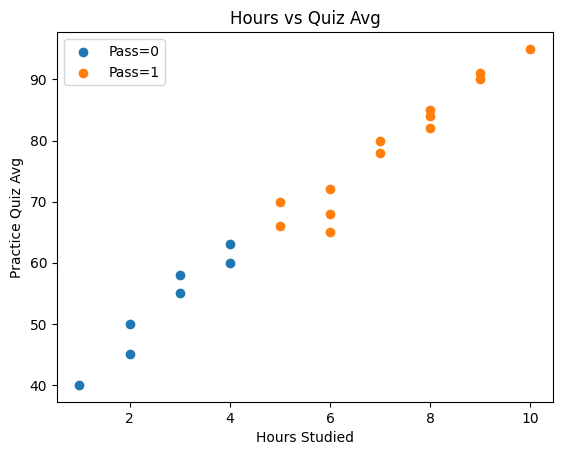

In [4]:
# b) Create at least two visualizations that help you judge whether Pass and Fail seem easy or hard to separate.
import matplotlib.pyplot as plt
plt.figure()

for label in [0, 1]:
    subset = df[df["Pass"] == label]
    plt.scatter(subset["Hours_Studied"], subset["Practice_Quiz_Avg"], label=f"Pass={label}")

plt.xlabel("Hours Studied")
plt.ylabel("Practice Quiz Avg")
plt.title("Hours vs Quiz Avg")
plt.legend()

plt.show()

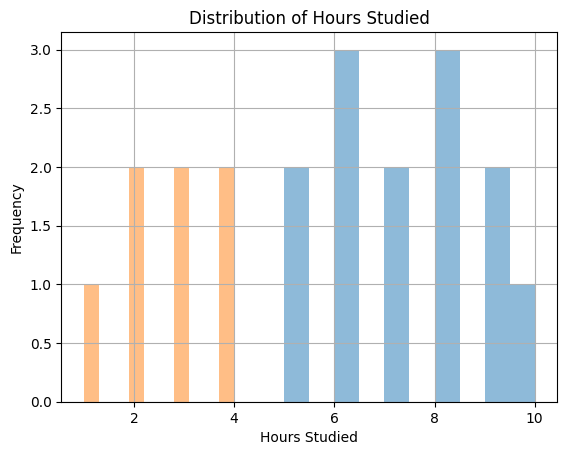

In [5]:
plt.figure()

df[df["Pass"] == 1]["Hours_Studied"].hist(alpha=0.5)
df[df["Pass"] == 0]["Hours_Studied"].hist(alpha=0.5)

plt.title("Distribution of Hours Studied")
plt.xlabel("Hours Studied")
plt.ylabel("Frequency")

plt.show()

In [6]:
#  Define X and y for the classification task, then split the data into training and test sets.
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Pass"])
Y = df["Pass"]
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

# Train a DecisionTreeClassifier with max_depth=2.
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=2)

model.fit(X_train, y_train)

# Predict on the test set and compute the confusion matrix, accuracy, precision, recall, and F1-score.

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)




Confusion Matrix:
 [[0 1]
 [0 3]]
Accuracy: 0.75
Precision: 0.75
Recall: 1.0
F1-score: 0.8571428571428571


Interpret TP, TN, FP, and FN in the context of student pass prediction.

TP	Correctly predicted passing student

TN	Correctly predicted failing student

FP	Predicted pass but actually fail

FN	Predicted fail but actually pass

In [7]:
# g) Create three new unseen student cases and predict whether each one will pass or fail.
import pandas as pd

new_students = pd.DataFrame([
    [2, 60, 55, 2.0],   # weak student
    [7, 85, 80, 3.2],   # average/good student
    [10, 95, 90, 3.9]   # strong student
], columns=["Hours_Studied", "Attendance", "Practice_Quiz_Avg", "Previous_GPA"])

predictions = model.predict(new_students)

print(predictions)

for i, pred in enumerate(predictions):
    result = "Pass" if pred == 1 else "Fail"
    print(f"Student {i+1}: {result}")

[0 1 1]
Student 1: Fail
Student 2: Pass
Student 3: Pass


1) Why is this a classification problem and not a regression problem?

This is a classification problem because the output (Pass) is categorical, not continuous. The model predicts only two possible outcomes: Pass (1) or Fail (0). Regression would be used if we were predicting a continuous value, like an exact exam score.

2) What does a false positive mean in this task?

A false positive means the model predicts that a student will Pass, but in reality the student actually Fails. This is a wrong positive prediction because the model incorrectly labels a weak student as successful.

3) Which metric would you trust most here, and why?

The most important metric here is usually recall, because it measures how many actual passing students are correctly identified. In an educational context, missing a student who will pass (false negative) can be more problematic than some incorrect predictions. However, in a balanced evaluation, F1-score is also useful because it considers both precision and recall together.

**Question 9 - Classification Topic 2: Support Ticket Escalation Risk**

Predict whether a support ticket will be escalated by comparing two decision-tree depths.

Tasks

a) Create a dataset with at least 20 support tickets and the columns Waiting_Time_Hours, Issue_Severity, Previous_Reopens, Customer_Priority, Agent_Experience, and Escalated.

b) Create at least two scatter plots or category-based plots that help you judge how strongly the classes overlap.

c) Split the data into training and test sets.

d) Train Classifier A using DecisionTreeClassifier(max_depth=1) and Classifier B using DecisionTreeClassifier(max_depth=2).

e) Use the same train/test split for both classifiers.

f) For both models, compute the confusion matrix, accuracy, precision, recall, and F1-score.

g) Compare the two classifiers and decide which one generalizes better to unseen data.

h) Explain one realistic business consequence of a false negative in this scenario.

Required written reflection

- How does stronger class overlap make classification harder?

- Why is it not enough to judge a classifier using only one metric?

- How is this question connected to overfitting versus generalization?

In [8]:
# Create a dataset with at least 20 support tickets and the columns Waiting_Time_Hours, Issue_Severity, Previous_Reopens, Customer_Priority, Agent_Experience, and Escalated.
data = {
    "Waiting_Time_Hours": [2, 5, 10, 1, 8, 12, 3, 6, 9, 4,
                           7, 2, 11, 5, 13, 6, 3, 8, 10, 1],

    "Issue_Severity": [2, 3, 5, 1, 4, 5, 2, 3, 4, 2,
                       3, 1, 5, 3, 5, 4, 2, 4, 5, 1],

    "Previous_Reopens": [0, 1, 3, 0, 2, 4, 0, 1, 2, 1,
                         2, 0, 3, 1, 4, 2, 0, 2, 3, 0],

    "Customer_Priority": [1, 2, 3, 1, 2, 3, 1, 2, 3, 2,
                          2, 1, 3, 2, 3, 2, 1, 3, 3, 1],

    "Agent_Experience": [5, 4, 2, 6, 3, 1, 5, 4, 2, 5,
                         3, 6, 1, 4, 1, 3, 5, 2, 2, 6],

    "Escalated": [0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
                  1, 0, 1, 0, 1, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)
print(df)

    Waiting_Time_Hours  Issue_Severity  Previous_Reopens  Customer_Priority  \
0                    2               2                 0                  1   
1                    5               3                 1                  2   
2                   10               5                 3                  3   
3                    1               1                 0                  1   
4                    8               4                 2                  2   
5                   12               5                 4                  3   
6                    3               2                 0                  1   
7                    6               3                 1                  2   
8                    9               4                 2                  3   
9                    4               2                 1                  2   
10                   7               3                 2                  2   
11                   2               1              

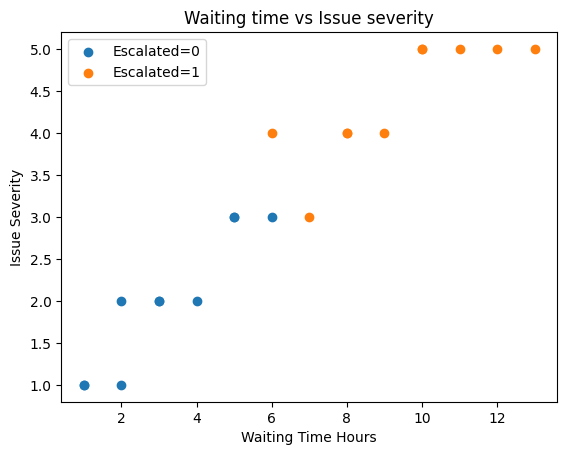

In [9]:
# b) Create at least two scatter plots or category-based plots that help you judge how strongly the classes overlap.
plt.figure()

for label in [0,1]:
  subset = df[df['Escalated']== label]
  plt.scatter(subset["Waiting_Time_Hours"],subset["Issue_Severity"],label=f"Escalated={label}")

plt.xlabel("Waiting Time Hours")
plt.ylabel("Issue Severity")
plt.title("Waiting time vs Issue severity")
plt.legend()

plt.show()

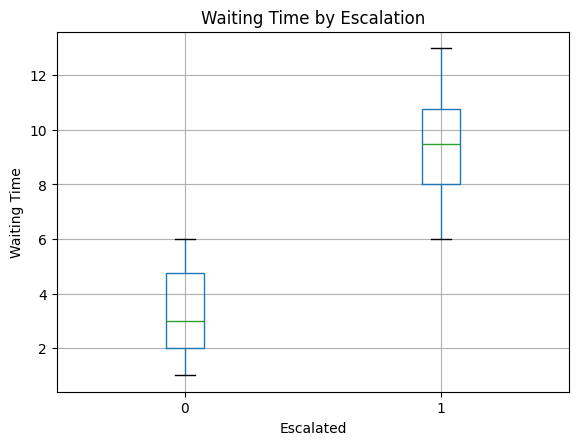

In [10]:
import matplotlib.pyplot as plt

df.boxplot(column="Waiting_Time_Hours", by="Escalated")

plt.title("Waiting Time by Escalation")
plt.suptitle("")
plt.xlabel("Escalated")
plt.ylabel("Waiting Time")
plt.show()

In [11]:
# c) Split the data into training and test sets.
x = df.drop(columns=["Escalated"])
y = df["Escalated"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=3)

# d) Train Classifier A using DecisionTreeClassifier(max_depth=1) and Classifier B using DecisionTreeClassifier(max_depth=2).
classifierA = DecisionTreeClassifier(max_depth=1)
classifierB = DecisionTreeClassifier(max_depth=2)

# e) Use the same train/test split for both classifiers.
classifierA.fit(x_train,y_train)
classifierB.fit(x_train,y_train)

y_predA = classifierA.predict(x_test)
y_predB= classifierB.predict(x_test)

# f) For both models, compute the confusion matrix, accuracy, precision, recall, and F1-score.

# Confusion Matrix
cmA = confusion_matrix(y_test, y_predA)
cmB = confusion_matrix(y_test, y_predB)

# Metrics
accuracyA = accuracy_score(y_test, y_predA)
precisionA = precision_score(y_test, y_predA)
recallA = recall_score(y_test, y_predA)
f1A = f1_score(y_test, y_predA)

accuracyB = accuracy_score(y_test, y_predB)
precisionB = precision_score(y_test, y_predB)
recallB = recall_score(y_test, y_predB)
f1B = f1_score(y_test, y_predB)

print("Confusion Matrix of classifier A:\n", cmA)
print("Accuracy:", accuracyA)
print("Precision:", precisionA)
print("Recall:", recallA)
print("F1-score:", f1A)

print("Confusion Matrix of classifier B:\n", cmB)
print("Accuracy of classifier B:", accuracyB)
print("Precision of classifier B:", precisionB)
print("Recall of classifier B:", recallB)
print("F1-score of classifier B:", f1B)


print("A:", y_predA)
print("B:", y_predB)



Confusion Matrix of classifier A:
 [[1 0]
 [0 3]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix of classifier B:
 [[1 0]
 [0 3]]
Accuracy of classifier B: 1.0
Precision of classifier B: 1.0
Recall of classifier B: 1.0
F1-score of classifier B: 1.0
A: [1 1 0 1]
B: [1 1 0 1]


g) Compare the two classifiers and decide which one generalizes better to unseen data.

Both classifiers produce identical predictions and evaluation metrics on the test set. However, Classifier A (max_depth=1) is preferred because it is simpler and less prone to overfitting. Since Classifier B does not improve performance, it adds unnecessary complexity. Therefore, Classifier A generalizes better to unseen data.

1) How does stronger class overlap make classification harder?

When classes overlap, the same or very similar feature values appear in both classes (e.g., both Escalated = 0 and 1 have similar waiting times or severity). This makes it difficult for the model to draw a clear boundary between them, leading to more misclassifications. The more overlap there is, the less separable the data is, and the harder it is for any classifier to perform well.

2) Why is it not enough to judge a classifier using only one metric?

A single metric (like accuracy) does not give the full picture of model performance. For example, a model can have high accuracy but still perform poorly on detecting a specific class. Metrics like precision, recall, and F1-score capture different types of errors (false positives and false negatives). Therefore, multiple metrics are needed to properly evaluate performance from different perspectives.

3) How is this question connected to overfitting versus generalization?

This question relates to overfitting and generalization because a model that performs well on training data but poorly on unseen data is overfitting. A good model should generalize well, meaning it performs consistently on new data. Class overlap and evaluation metrics help reveal whether the model has learned real patterns (generalization) or just memorized the training data (overfitting).

**Question 10 - Classification Topic 3: Customer Churn Warning System**

 Build a classification task in a business setting and analyze why accuracy alone can be misleading.
 Tasks
  
  a) Create a dataset with at least 24 customers and the columns Visits_Per_Month, Support_Tickets, Monthly_Spend, Tenure_Months, Satisfaction_Score, and Churn.
  
  b) Make the dataset slightly imbalanced so that one class appears more often than the other. Print the class counts clearly.
  
  c) Inspect the data and create at least two plots that help you reason about possible separation between the classes.
  
  d) Define X and y, split the data, and train a DecisionTreeClassifier with max_depth=2.
  
  e) Predict on the test set and compute the confusion matrix, accuracy, precision, recall, and F1-score.
  
  f) Explain why a model can have acceptable accuracy while still performing poorly on the more important class.
  
  g) Create three hypothetical customers and predict whether each one is likely to churn.
  
  Required written reflection
  
  - Why can accuracy be misleading when the classes are imbalanced?
  
  - Which metric would you examine carefully if missing a churn case is costly, and why?
  
  - What does this question teach about evaluating classification models in real projects?

Churn
0    15
1     9
Name: count, dtype: int64


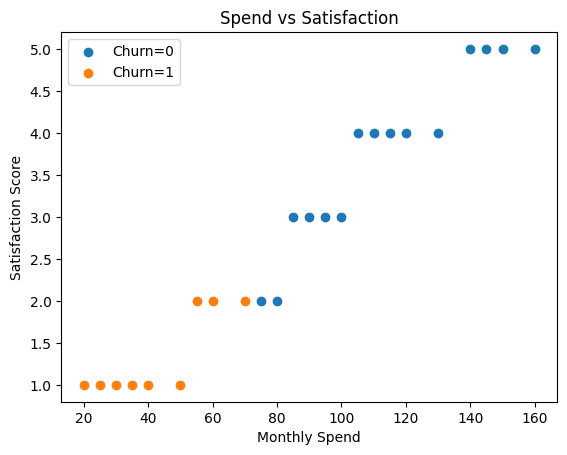

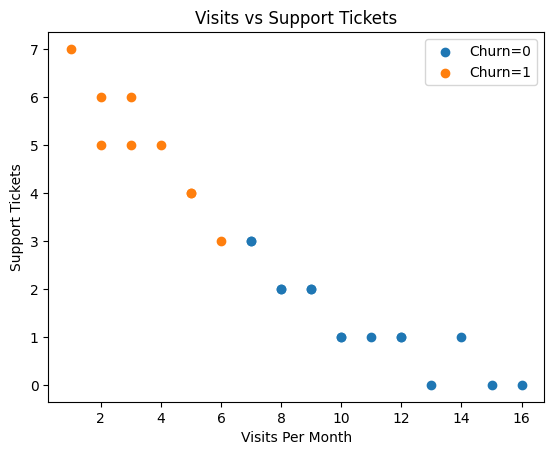

Confusion Matrix:
 [[3 0]
 [0 2]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Customer 1: Churn
Customer 2: No Churn
Customer 3: Churn


In [12]:
# a) Create a dataset with at least 24 customers and the columns Visits_Per_Month, Support_Tickets, Monthly_Spend, Tenure_Months, Satisfaction_Score, and Churn.

data = {
    "Visits_Per_Month": [12, 8, 3, 15, 10, 2, 7, 14, 5, 9, 11, 4,
                         6, 13, 1, 16, 8, 3, 10, 12, 2, 7, 9, 5],

    "Support_Tickets": [1, 2, 5, 0, 1, 6, 3, 1, 4, 2, 1, 5,
                        3, 0, 7, 0, 2, 6, 1, 1, 5, 3, 2, 4],

    "Monthly_Spend": [120, 90, 40, 150, 110, 30, 80, 140, 60, 100, 130, 50,
                      70, 145, 20, 160, 85, 35, 105, 115, 25, 75, 95, 55],

    "Tenure_Months": [24, 18, 5, 30, 22, 3, 15, 28, 8, 20, 25, 6,
                      10, 26, 2, 32, 17, 4, 21, 23, 3, 14, 19, 7],

    "Satisfaction_Score": [4, 3, 1, 5, 4, 1, 2, 5, 2, 3, 4, 1,
                           2, 5, 1, 5, 3, 1, 4, 4, 1, 2, 3, 2],

    "Churn": [0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
              1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1]
}

df = pd.DataFrame(data)

# b) Make the dataset slightly imbalanced so that one class appears more often than the other. Print the class counts clearly.
print(df["Churn"].value_counts())

  # c) Inspect the data and create at least two plots that help you reason about possible separation between the classes.

for label in [0, 1]:
    subset = df[df["Churn"] == label]
    plt.scatter(subset["Monthly_Spend"], subset["Satisfaction_Score"],
                label=f"Churn={label}")

plt.xlabel("Monthly Spend")
plt.ylabel("Satisfaction Score")
plt.legend()
plt.title("Spend vs Satisfaction")
plt.show()

for label in [0, 1]:
    subset = df[df["Churn"] == label]
    plt.scatter(subset["Visits_Per_Month"], subset["Support_Tickets"],
                label=f"Churn={label}")

plt.xlabel("Visits Per Month")
plt.ylabel("Support Tickets")
plt.legend()
plt.title("Visits vs Support Tickets")
plt.show()

  # d) Define X and y, split the data, and train a DecisionTreeClassifier with max_depth=2.

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=2)
model.fit(X_train, y_train)

  # e) Predict on the test set and compute the confusion matrix, accuracy, precision, recall, and F1-score.

y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

  # g) Create three hypothetical customers and predict whether each one is likely to churn.

new_customers = pd.DataFrame([
    [5, 4, 60, 10, 2],   # likely churn
    [12, 1, 140, 30, 5], # likely no churn
    [2, 6, 30, 3, 1]     # likely churn
], columns=["Visits_Per_Month", "Support_Tickets", "Monthly_Spend",
            "Tenure_Months", "Satisfaction_Score"])

pred = model.predict(new_customers)

for i, p in enumerate(pred):
    print(f"Customer {i+1}: {'Churn' if p==1 else 'No Churn'}")

f) Explain why a model can have acceptable accuracy while still performing poorly on the more important class.

A model can still have high accuracy but perform poorly on the important class (Churn = 1) because the dataset is imbalanced. If most customers do not churn, the model can predict “no churn” most of the time and still appear accurate, even if it fails to detect churn customers correctly. This leads to misleading performance evaluation.

1. Why can accuracy be misleading?

Accuracy can be misleading in imbalanced datasets because the model can predict the majority class most of the time and still achieve high accuracy, even if it fails to detect the minority class.

2. Which metric matters most?

Recall is most important because it measures how many actual churn customers are correctly identified. Missing a churn customer is costly, so minimizing false negatives is critical.

3. What does this teach?

This question teaches that model evaluation in real-world problems must consider data imbalance and business impact, not just accuracy. Different metrics are needed depending on the problem’s goal.